In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Load data
df = pd.read_csv("data.txt", sep=';', parse_dates={'Datetime': ['Date', 'Time']}, infer_datetime_format=True, low_memory=False, na_values=['?'])

# Convert datetime and set index
df['Datetime'] = pd.to_datetime(df['Datetime'])
df.set_index('Datetime', inplace=True)

# Convert to numeric (some entries are strings or '?')
df['Global_active_power'] = pd.to_numeric(df['Global_active_power'], errors='coerce')
df.dropna(subset=['Global_active_power'], inplace=True)

df.head()


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
Datetime,,,,,,,
2006-12-16 17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
2006-12-16 17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2006-12-16 17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
2006-12-16 17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
2006-12-16 17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


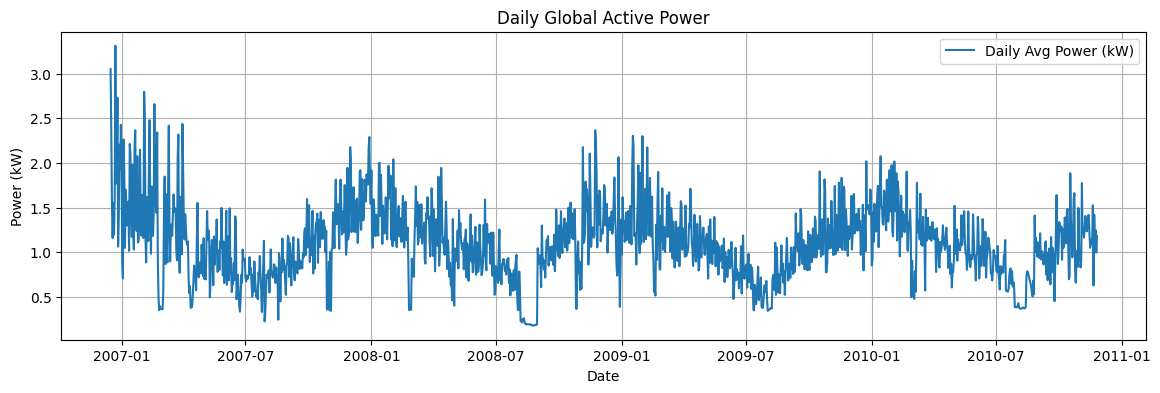

In [21]:
# Resample to daily average
df_daily = df['Global_active_power'].resample('D').mean()
df_daily.dropna(inplace=True)
df_daily.to_csv("Final_data.csv")
plt.figure(figsize=(14, 4))
plt.plot(df_daily, label='Daily Avg Power (kW)')
plt.title("Daily Global Active Power")
plt.xlabel("Date")
plt.ylabel("Power (kW)")
plt.grid(True)
plt.legend()
plt.show()


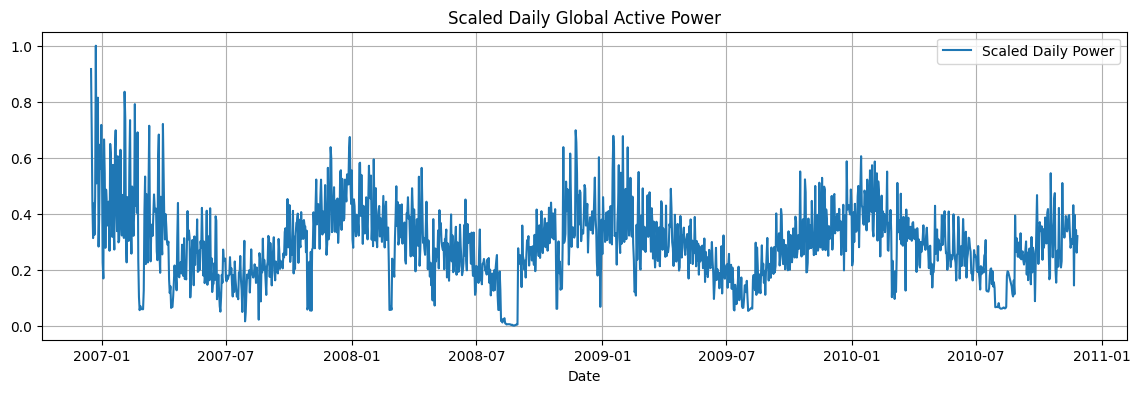

In [20]:
# Scale data to [0, 1] range for better model performance
scaler = MinMaxScaler()
scaled_series = scaler.fit_transform(df_daily.values.reshape(-1, 1))
df_daily_scaled = pd.Series(scaled_series.flatten(), index=df_daily.index)
df_daily_scaled.to_csv('fnal_data.csv')
plt.figure(figsize=(14, 4))
plt.plot(df_daily_scaled, label='Scaled Daily Power')
plt.title("Scaled Daily Global Active Power")
plt.xlabel("Date")
plt.grid(True)
plt.legend()
plt.show()


In [5]:
# Augmented Dickey-Fuller test
result = adfuller(df_daily_scaled)

print(f'ADF Statistic: {result[0]:.4f}')
print(f'p-value: {result[1]:.4f}')
if result[1] < 0.05:
    print("✅ Series is stationary")
else:
    print("❌ Series is not stationary, applying differencing...")


ADF Statistic: -3.6842
p-value: 0.0043
✅ Series is stationary


In [7]:
# Train-Test split on scaled (stationary) data
train_size = int(len(df_daily_scaled) * 0.8)
train, test = df_daily_scaled[:train_size], df_daily_scaled[train_size:]

print(f"Train size: {len(train)}")
print(f"Test size: {len(test)}")


Train size: 1146
Test size: 287


In [15]:
from statsmodels.tsa.arima.model import ARIMA

# Since data is stationary, d = 0
model = ARIMA(train, order=(5, 0, 1))
model_fit = model.fit()

# Summary
print(model_fit.summary())


                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 1146
Model:                 ARIMA(5, 0, 1)   Log Likelihood                 985.844
Date:                Tue, 22 Apr 2025   AIC                          -1955.688
Time:                        12:53:24   BIC                          -1915.336
Sample:                             0   HQIC                         -1940.453
                               - 1146                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.3038      0.018     16.423      0.000       0.268       0.340
ar.L1          0.0132      0.422      0.031      0.975      -0.814       0.840
ar.L2          0.1728      0.177      0.976      0.3

In [16]:
# Forecast on test set
forecast = model_fit.forecast(steps=len(test))
forecast.index = test.index

# Metrics
mae = mean_absolute_error(test, forecast)
rmse = np.sqrt(mean_squared_error(test, forecast))
r2 = r2_score(test, forecast)

print("📊 ARIMA Model Evaluation")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R² Score: {r2:.4f}")


📊 ARIMA Model Evaluation
Mean Absolute Error (MAE): 0.0825
Root Mean Squared Error (RMSE): 0.1061
R² Score: -0.1240


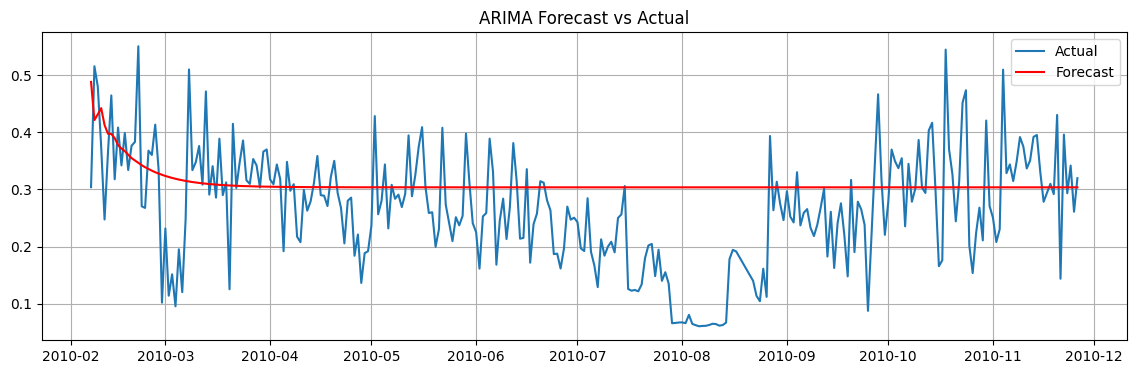

In [17]:
plt.figure(figsize=(14, 4))
plt.plot(test, label='Actual')
plt.plot(forecast, label='Forecast', color='red')
plt.title("ARIMA Forecast vs Actual")
plt.grid(True)
plt.legend()
plt.show()
